In [75]:
import polars as pl
from pathlib import Path

# Определяем базовую директорию (папка, где лежит скрипт)
# В Jupyter/IPython используйте Path.cwd(), в .py файлах можно Path(__file__).parent
base_dir = Path.cwd() 

# Указываем пути относительно корня проекта
data_path = base_dir / "data.csv"
events_path = base_dir / "events.csv"


In [76]:
import polars as pl

# Снимаем ограничения на количество выводимых столбцов и их ширину
pl.Config.set_tbl_cols(-1)       # -1 означает выводить все столбцы
pl.Config.set_tbl_width_chars(1000) # Увеличиваем ширину вывода в символах



# Ленивое чтение
users_scan = pl.scan_csv(data_path)
events_scan = pl.scan_csv(events_path)



In [77]:
import polars as pl

# Считаем количество событий каждого типа
event_counts = (
    events_scan
    .group_by("event_type")
    .agg(pl.len().alias("count"))
    .sort("count", descending=True)
    .collect()
)

print("--- Распределение типов событий ---")
print(event_counts)

--- Распределение типов событий ---
shape: (6, 2)
┌────────────┬─────────┐
│ event_type ┆ count   │
│ ---        ┆ ---     │
│ str        ┆ u32     │
╞════════════╪═════════╡
│ product    ┆ 1692792 │
│ department ┆ 1192730 │
│ cart       ┆ 1191982 │
│ purchase   ┆ 363852  │
│ cancel     ┆ 249360  │
│ home       ┆ 174608  │
└────────────┴─────────┘


In [78]:
import polars as pl

# 1. Очистка от технических дублей и заполнение user_id внутри сессий
events_filled = (
    events_scan
    # Убираем полные дубликаты (события с одинаковым временем для одного юзера/сессии)
    .unique(subset=["session_id", "created_at", "event_type"])
    .with_columns(
        # Группируем по сессии и берем первое не-null значение user_id
        # "min" или "max" сработают, если в сессии только один уникальный ID
        pl.col("user_id").min().over("session_id").alias("filled_user_id")
    )
    # Теперь используем заполненный ID, если исходный был null
    .with_columns(
        final_user_id = pl.coalesce(["filled_user_id", "user_id"])
    )
)

# 2. Пересчет матрицы переходов на чистых данных
# Используем final_user_id для изоляции траекторий
transition_matrix_clean = (
    events_filled
    .sort(["final_user_id", "created_at"])
    .with_columns(
        next_event = pl.col("event_type").shift(-1).over("final_user_id")
    )
    # Исключаем самопереходы и концы цепочек
    .filter(
        pl.col("next_event").is_not_null() & 
        (pl.col("event_type") != pl.col("next_event"))
    )
    .group_by(["event_type", "next_event"])
    .agg(pl.len().alias("count"))
    .with_columns(
        probability = (pl.col("count") / pl.col("count").sum().over("event_type")).round(4)
    )
    .sort(["event_type", "probability"], descending=[False, True])
    .collect()
)

print("--- Очищенная матрица переходов (без дублей и с восстановленными ID) ---")
print(transition_matrix_clean)

--- Очищенная матрица переходов (без дублей и с восстановленными ID) ---
shape: (26, 4)
┌────────────┬────────────┬────────┬─────────────┐
│ event_type ┆ next_event ┆ count  ┆ probability │
│ ---        ┆ ---        ┆ ---    ┆ ---         │
│ str        ┆ str        ┆ u32    ┆ f64         │
╞════════════╪════════════╪════════╪═════════════╡
│ cancel     ┆ product    ┆ 54675  ┆ 0.4906      │
│ cancel     ┆ department ┆ 28758  ┆ 0.258       │
│ cancel     ┆ cart       ┆ 28011  ┆ 0.2513      │
│ cart       ┆ department ┆ 248015 ┆ 0.461       │
│ cart       ┆ purchase   ┆ 134709 ┆ 0.2504      │
│ cart       ┆ product    ┆ 117593 ┆ 0.2186      │
│ cart       ┆ cancel     ┆ 37348  ┆ 0.0694      │
│ cart       ┆ home       ┆ 289    ┆ 0.0005      │
│ department ┆ product    ┆ 454166 ┆ 0.8482      │
│ department ┆ cart       ┆ 56839  ┆ 0.1062      │
│ department ┆ cancel     ┆ 23743  ┆ 0.0443      │
│ department ┆ purchase   ┆ 450    ┆ 0.0008      │
│ department ┆ home       ┆ 256    ┆ 0.0005  

In [79]:
# 1. Извлекаем вероятности из матрицы для нашей цепочки
p = {f"{row['event_type']}->{row['next_event']}": row['probability'] 
     for row in transition_matrix_clean.to_dicts()}

# 2. Определяем этапы воронки
steps = ["home", "department", "product", "cart", "purchase"]

funnel_data = []
current_conv = 1.0  # Интегральная вероятность (Conversion)

for i in range(len(steps)):
    step_name = steps[i]
    
    if i == 0:
        # Начальное состояние (Ground State)
        step_prob = 1.0
        drop_off = 0.0
    else:
        # Вероятность перехода из i-1 в i
        prev_step = steps[i-1]
        step_prob = p.get(f"{prev_step}->{step_name}", 0.0)
        current_conv *= step_prob
        drop_off = 1.0 - step_prob

    funnel_data.append({
        "step": f"{i+1}. {step_name.capitalize()}",
        "conversion": round(current_conv, 4),
        "step_probability": round(step_prob, 4),
        "drop_off": round(drop_off, 4)
    })

df_funnel_final = pl.DataFrame(funnel_data)
print("--- Итоговая воронка без NULL ---")
print(df_funnel_final)

--- Итоговая воронка без NULL ---
shape: (5, 4)
┌───────────────┬────────────┬──────────────────┬──────────┐
│ step          ┆ conversion ┆ step_probability ┆ drop_off │
│ ---           ┆ ---        ┆ ---              ┆ ---      │
│ str           ┆ f64        ┆ f64              ┆ f64      │
╞═══════════════╪════════════╪══════════════════╪══════════╡
│ 1. Home       ┆ 1.0        ┆ 1.0              ┆ 0.0      │
│ 2. Department ┆ 0.9945     ┆ 0.9945           ┆ 0.0055   │
│ 3. Product    ┆ 0.8435     ┆ 0.8482           ┆ 0.1518   │
│ 4. Cart       ┆ 0.6079     ┆ 0.7207           ┆ 0.2793   │
│ 5. Purchase   ┆ 0.1522     ┆ 0.2504           ┆ 0.7496   │
└───────────────┴────────────┴──────────────────┴──────────┘


In [80]:
# Сравним объем данных для анализа
old_data_volume = events_scan.filter(pl.col("user_id").is_not_null()).collect().height
new_data_volume = events_filled.collect().height

print(f"Объем данных для анализа вырос на: {new_data_volume - old_data_volume} строк")
print(f"Это события, которые раньше были 'ничьими', а теперь обрели владельца.")

Объем данных для анализа вырос на: -184174 строк
Это события, которые раньше были 'ничьими', а теперь обрели владельца.


In [81]:
import polars as pl

# 1. Считаем метрики до и после заполнения
# Берем исходный events_scan и наш очищенный events_filled
metrics = (
    events_scan
    .select([
        # Общее кол-во событий в системе
        pl.len().alias("total_rows"),
        # События, где ID был изначально
        pl.col("user_id").is_not_null().sum().alias("initially_identified"),
        # События, где ID был null
        pl.col("user_id").is_null().sum().alias("initially_anonymous")
    ])
    .collect()
)

# 2. Считаем, сколько из анонимных мы "спасли"
# (Это те, у кого в events_filled теперь есть final_user_id)
recovered_count = (
    events_filled
    .filter(pl.col("user_id").is_null()) # Берем только те, что были null
    .select(pl.len())
    .collect()
    .item()
)

total = metrics["total_rows"][0]
initial_id = metrics["initially_identified"][0]
initial_anon = metrics["initially_anonymous"][0]

print("--- Результаты де-анонимизации ---")
print(f"Всего событий в логах:      {total:,}")
print(f"Были с ID изначально:      {initial_id:,} ({initial_id/total:.1%})")
print(f"Были анонимными (null):    {initial_anon:,} ({initial_anon/total:.1%})")
print(f"---")
print(f"Восстановлено через сессии: {recovered_count:,}")
print(f"Эффективность «протяжки»:   {recovered_count/initial_anon:.1%} от всех анонимов")

--- Результаты де-анонимизации ---
Всего событий в логах:      4,865,324
Были с ID изначально:      2,616,836 (53.8%)
Были анонимными (null):    2,248,488 (46.2%)
---
Восстановлено через сессии: 1,124,244
Эффективность «протяжки»:   50.0% от всех анонимов


In [82]:
import polars as pl

# Используем events_filled, но фильтруем тех, кто ТАК И НЕ получил ID (чистые анонимы)
anon_transitions = (
    events_filled
    .filter(pl.col("final_user_id").is_null()) 
    .sort(["session_id", "created_at"])
    # Сдвиг делаем внутри сессии, так как это единственный надежный трек для анонима
    .with_columns(
        next_event = pl.col("event_type").shift(-1).over("session_id")
    )
    .filter(pl.col("next_event").is_not_null())
    .group_by(["event_type", "next_event"])
    .agg(pl.len().alias("count"))
    .with_columns(
        prob = (pl.col("count") / pl.col("count").sum().over("event_type")).round(4)
    )
    .sort("count", descending=True)
    .collect()
)

print("--- Реальные пути анонимов (Топ-10) на базе events_filled ---")
print(anon_transitions.head(10))

--- Реальные пути анонимов (Топ-10) на базе events_filled ---
shape: (10, 4)
┌────────────┬────────────┬────────┬────────┐
│ event_type ┆ next_event ┆ count  ┆ prob   │
│ ---        ┆ ---        ┆ ---    ┆ ---    │
│ str        ┆ str        ┆ u32    ┆ f64    │
╞════════════╪════════════╪════════╪════════╡
│ department ┆ product    ┆ 243832 ┆ 0.9835 │
│ product    ┆ cart       ┆ 241454 ┆ 0.9677 │
│ cart       ┆ cancel     ┆ 120684 ┆ 0.9667 │
│ cart       ┆ product    ┆ 4108   ┆ 0.0329 │
│ department ┆ cart       ┆ 4102   ┆ 0.0165 │
│ product    ┆ department ┆ 4102   ┆ 0.0164 │
│ product    ┆ cancel     ┆ 3948   ┆ 0.0158 │
│ cancel     ┆ cart       ┆ 1925   ┆ 0.9767 │
│ cancel     ┆ product    ┆ 46     ┆ 0.0233 │
│ cart       ┆ department ┆ 43     ┆ 0.0003 │
└────────────┴────────────┴────────┴────────┘


In [121]:
import polars as pl

def calculate_full_funnel_comprehensive(df_lazy, group_name):
    # Используем final_user_id как основной ключ, если его нет — session_id
    # Но в твоем events_filled мы ориентируемся на final_user_id
    id_col = "final_user_id"

    # 1. Считаем абсолюты (Unique Users)
    abs_counts = (
        df_lazy
        .group_by("event_type")
        .agg(pl.col(id_col).n_unique().alias("unique_users"))
        .collect()
    )
    counts_dict = {r["event_type"]: r["unique_users"] for r in abs_counts.to_dicts()}

    # 2. Матрица переходов (Probability Matrix)
    matrix = (
        df_lazy
        .sort([id_col, "created_at"])
        .with_columns(next_event = pl.col("event_type").shift(-1).over(id_col))
        .filter(pl.col("next_event").is_not_null() & (pl.col("event_type") != pl.col("next_event")))
        .group_by(["event_type", "next_event"])
        .agg(pl.len().alias("count"))
        .with_columns(prob = (pl.col("count") / pl.col("count").sum().over("event_type")))
        .collect()
    )
    
    p = {f"{r['event_type']}->{r['next_event']}": r['prob'] for r in matrix.to_dicts()}
    
    # 3. Цепочка (Home -> Dept -> Product -> Cart)
    steps = ["home", "department", "product", "cart"]
    funnel_res = []
    
    has_home = any(k.startswith("home->") for k in p.keys())
    current_conv = 1.0
    
    for i, s in enumerate(steps):
        u_count = counts_dict.get(s, 0)
        
        if i == 0:
            step_prob = 1.0 if has_home else 0.0
        elif s == "department" and not has_home:
            # Если нет home (анонимы), стартуем с department как 100%
            step_prob = 1.0
            current_conv = 1.0 
        else:
            step_prob = p.get(f"{steps[i-1]}->{s}", 0.0)
            
        current_conv *= step_prob
        
        funnel_res.append({
            "step": s,
            "abs_count": u_count,
            "conversion": round(current_conv, 4),
            "step_p": round(step_prob, 4),
            "drop_off": round(1.0 - step_prob, 4) if step_prob > 0 else (1.0 if i > 0 else 0.0)
        })
        
    # 4. Финал: PURCHASE / CANCEL
    for final_step in ["purchase", "cancel"]:
        p_final = p.get(f"cart->{final_step}", 0.0)
        u_count = counts_dict.get(final_step, 0)
        
        funnel_res.append({
            "step": final_step.upper(), 
            "abs_count": u_count,
            "conversion": round(current_conv * p_final, 4), 
            "step_p": round(p_final, 4),
            "drop_off": round(1.0 - p_final, 4)
        })
    
    return pl.DataFrame(funnel_res).with_columns(group = pl.lit(group_name))

# --- РАЗДЕЛЬНЫЙ ЗАПУСК ---

# Авторизованные (те, у кого был user_id изначально)
full_auth = calculate_full_funnel_comprehensive(
    events_filled.filter(pl.col("filled_user_id").is_not_null()), 
    "Authorized"
)

# Анонимы (те, кто так и остался без user_id после заполнения по сессии)
full_anon = calculate_full_funnel_comprehensive(
    events_filled.filter(pl.col("filled_user_id").is_null()), 
    "Anonymous"
)

# --- ВЫВОД ---

print("--- ПОЛНАЯ ВОРОНКА: АВТОРИЗОВАННЫЕ ---")
print(full_auth)

print("\n--- ПОЛНАЯ ВОРОНКА: АНОНИМЫ ---")
print(full_anon)

# Сравнение только по конверсии для удобства
comparison = pl.concat([full_auth, full_anon]).pivot(
    on="group", index="step", values="conversion"
).sort(pl.col("step").replace({
    "home": 0, "department": 1, "product": 2, "cart": 3, "PURCHASE": 4, "CANCEL": 5
}))

print("\n--- СРАВНИТЕЛЬНЫЙ CR (ОТ ВХОДА) ---")
print(comparison)

--- ПОЛНАЯ ВОРОНКА: АВТОРИЗОВАННЫЕ ---
shape: (6, 6)
┌────────────┬───────────┬────────────┬────────┬──────────┬────────────┐
│ step       ┆ abs_count ┆ conversion ┆ step_p ┆ drop_off ┆ group      │
│ ---        ┆ ---       ┆ ---        ┆ ---    ┆ ---      ┆ ---        │
│ str        ┆ i64       ┆ f64        ┆ f64    ┆ f64      ┆ str        │
╞════════════╪═══════════╪════════════╪════════╪══════════╪════════════╡
│ home       ┆ 62967     ┆ 1.0        ┆ 1.0    ┆ 0.0      ┆ Authorized │
│ department ┆ 80021     ┆ 0.9947     ┆ 0.9947 ┆ 0.0053   ┆ Authorized │
│ product    ┆ 80021     ┆ 0.9655     ┆ 0.9707 ┆ 0.0293   ┆ Authorized │
│ cart       ┆ 80021     ┆ 0.9346     ┆ 0.968  ┆ 0.032    ┆ Authorized │
│ PURCHASE   ┆ 80021     ┆ 0.372      ┆ 0.398  ┆ 0.602    ┆ Authorized │
│ CANCEL     ┆ 0         ┆ 0.0        ┆ 0.0    ┆ 1.0      ┆ Authorized │
└────────────┴───────────┴────────────┴────────┴──────────┴────────────┘

--- ПОЛНАЯ ВОРОНКА: АНОНИМЫ ---
shape: (6, 6)
┌────────────┬──────────

In [133]:
import polars as pl

def get_transition_matrices(df_lazy, label):
    id_col = "final_user_id"
    
    # 1. Расчет переходов (цепочки событий)
    transitions = (
        df_lazy
        .sort([id_col, "created_at"])
        .with_columns(
            next_event = pl.col("event_type").shift(-1).over(id_col)
        )
        .filter(
            pl.col("next_event").is_not_null() & 
            (pl.col("event_type") != pl.col("next_event"))
        )
        .group_by(["event_type", "next_event"])
        .agg(pl.len().alias("count"))
        .collect()
    )
    
    # 2. Матрица Количеств (Переходы)
    counts_matrix = (
        transitions
        .pivot(on="next_event", index="event_type", values="count")
        .fill_null(0)
        .sort("event_type")
    )
    
    # 3. Матрица Вероятностей (Нормировка по строке)
    # Считаем сумму переходов из каждого состояния (энергия выхода)
    prob_matrix = (
        transitions
        .with_columns(
            prob = pl.col("count") / pl.col("count").sum().over("event_type")
        )
        .pivot(on="next_event", index="event_type", values="prob")
        .fill_null(0.0)
        .sort("event_type")
    )
    
    return counts_matrix, prob_matrix

# Разделяем потоки
auth_df = events_filled.filter(pl.col("filled_user_id").is_not_null())
anon_df = events_filled.filter(pl.col("filled_user_id").is_null())

# Получаем данные
auth_counts, auth_probs = get_transition_matrices(auth_df, "Authorized")
anon_counts, anon_probs = get_transition_matrices(anon_df, "Anonymous")

# --- ВЫВОД ---

print(f"{'='*20} АВТОРИЗОВАННЫЕ {'='*20}")
print("\nМАТРИЦА ПЕРЕХОДОВ (COUNT):")
print(auth_counts)
print("\nМАТРИЦА ВЕРОЯТНОСТЕЙ (PROBABILITY):")
print(auth_probs.select([pl.col("event_type"), pl.all().exclude("event_type").round(3)]))

print(f"\n{'='*20} АНОНИМЫ {'='*20}")
print("\nМАТРИЦА ПЕРЕХОДОВ (COUNT):")
print(anon_counts)
print("\nМАТРИЦА ВЕРОЯТНОСТЕЙ (PROBABILITY):")
print(anon_probs.select([pl.col("event_type"), pl.all().exclude("event_type").round(3)]))

==================== АВТОРИЗОВАННЫЕ ====================

МАТРИЦА ПЕРЕХОДОВ (COUNT):
shape: (5, 6)
┌────────────┬───────┬──────────┬────────────┬────────┬─────────┐
│ event_type ┆ home  ┆ purchase ┆ department ┆ cart   ┆ product │
│ ---        ┆ ---   ┆ ---      ┆ ---        ┆ ---    ┆ ---     │
│ str        ┆ u32   ┆ u32      ┆ u32        ┆ u32    ┆ u32     │
╞════════════╪═══════╪══════════╪════════════╪════════╪═════════╡
│ cart       ┆ 293   ┆ 134730   ┆ 193811     ┆ 0      ┆ 9565    │
│ department ┆ 230   ┆ 450      ┆ 0          ┆ 9148   ┆ 328548  │
│ home       ┆ 0     ┆ 1        ┆ 86851      ┆ 7      ┆ 444     │
│ product    ┆ 9     ┆ 1032     ┆ 9767       ┆ 328519 ┆ 0       │
│ purchase   ┆ 30991 ┆ 0        ┆ 23779      ┆ 895    ┆ 697     │
└────────────┴───────┴──────────┴────────────┴────────┴─────────┘

МАТРИЦА ВЕРОЯТНОСТЕЙ (PROBABILITY):
shape: (5, 6)
┌────────────┬───────┬──────────┬────────────┬───────┬─────────┐
│ event_type ┆ home  ┆ purchase ┆ department ┆ cart  ┆ prod

In [ ]:
import polars as pl

# 1. Жесткий базис состояний (наша "метрика" пространства)
STEPS_ORDER = ["home", "department", "product", "cart", "purchase", "cancel"]
ORDER_MAP = {step: i for i, step in enumerate(STEPS_ORDER)}

def sort_by_funnel_logic(df, col_name="step"):
    """Сортирует DataFrame по логике воронки (бизнес-цепочке)"""
    return (
        df.with_columns(
            sort_idx = pl.col(col_name).str.to_lowercase().replace(ORDER_MAP)
        )
        .sort("sort_idx")
        .drop("sort_idx")
    )

# 2. Исправленная функция расчета воронки
def calculate_segmented_funnel(df_lazy, segment_label):
    id_col = "final_user_id"

    # Абсолюты
    abs_counts = (
        df_lazy
        .group_by("event_type")
        .agg(pl.col(id_col).n_unique().alias("u_users"))
        .collect()
    )
    counts_dict = {r["event_type"]: r["u_users"] for r in abs_counts.to_dicts()}

    # Матрица переходов
    matrix = (
        df_lazy
        .sort([id_col, "created_at"])
        .with_columns(
            next_event = pl.col("event_type").shift(-1).over(id_col)
        )
        .filter(pl.col("next_event").is_not_null() & (pl.col("event_type") != pl.col("next_event")))
        .group_by(["event_type", "next_event"])
        .agg(pl.len().alias("count"))
        .with_columns(prob = (pl.col("count") / pl.col("count").sum().over("event_type")))
        .collect()
    )
    p = {f"{r['event_type']}->{r['next_event']}": r['prob'] for r in matrix.to_dicts()}

    funnel_rows = []
    curr_conv = 1.0
    
    # Идем строго по нашему базису STEPS_ORDER
    for i, s in enumerate(STEPS_ORDER):
        u_count = counts_dict.get(s, 0)
        
        # Для шагов после корзины (PURCHASE/CANCEL) считаем переход от cart
        if s in ["purchase", "cancel"]:
            p_step = p.get(f"cart->{s}", 0.0)
            conv = curr_conv * p_step # Это CR от входа до финала
        else:
            p_step = 1.0 if i == 0 else p.get(f"{STEPS_ORDER[i-1]}->{s}", 0.0)
            curr_conv *= p_step
            conv = curr_conv

        funnel_rows.append({
            "step": s.upper() if s in ["purchase", "cancel"] else s,
            "abs_count": u_count,
            "conversion": round(conv, 4),
            "step_p": round(p_step, 4),
            "drop_off": round(1.0 - p_step, 4) if i > 0 else 0.0
        })
    
    return pl.DataFrame(funnel_rows).with_columns(segment = pl.lit(segment_label))

# 3. Расчет и сборка
segments_list = ["One-timer", "Regular", "Heavy User"]
auth_funnels = [
    calculate_segmented_funnel(auth_events_with_segments.filter(pl.col("user_type") == s), s)
    for s in segments_list
]

# 4. Итоговое сравнение с адекватным порядком
full_results = pl.concat(auth_funnels)

# Пивотим и сортируем строки
comparison = (
    full_results
    .pivot(on="segment", index="step", values="conversion")
    .pipe(sort_by_funnel_logic, col_name="step")
)

print("--- СРАВНЕНИЕ КОНВЕРСИИ (ЛОГИЧЕСКИЙ ПОРЯДОК) ---")
print(comparison)

# Детальный вывод по каждому сегменту
for f in auth_funnels:
    print(f"\n--- Детально: {f['segment'][0]} ---")
    print(sort_by_funnel_logic(f).select(["step", "abs_count", "conversion", "step_p", "drop_off"]))

--- СРАВНЕНИЕ КОНВЕРСИИ (ЛОГИЧЕСКИЙ ПОРЯДОК) ---
shape: (6, 4)
┌────────────┬───────────┬─────────┬────────────┐
│ step       ┆ One-timer ┆ Regular ┆ Heavy User │
│ ---        ┆ ---       ┆ ---     ┆ ---        │
│ str        ┆ f64       ┆ f64     ┆ f64        │
╞════════════╪═══════════╪═════════╪════════════╡
│ home       ┆ 1.0       ┆ 1.0     ┆ 1.0        │
│ department ┆ 0.9947    ┆ 0.9944  ┆ 0.994      │
│ product    ┆ 0.9867    ┆ 0.9763  ┆ 0.9542     │
│ cart       ┆ 0.9783    ┆ 0.9569  ┆ 0.9125     │
│ PURCHASE   ┆ 0.9754    ┆ 0.4358  ┆ 0.2312     │
│ CANCEL     ┆ 0.0       ┆ 0.0     ┆ 0.0        │
└────────────┴───────────┴─────────┴────────────┘

--- Детально: One-timer ---
shape: (6, 5)
┌────────────┬───────────┬────────────┬────────┬──────────┐
│ step       ┆ abs_count ┆ conversion ┆ step_p ┆ drop_off │
│ ---        ┆ ---       ┆ ---        ┆ ---    ┆ ---      │
│ str        ┆ i64       ┆ f64        ┆ f64    ┆ f64      │
╞════════════╪═══════════╪════════════╪════════╪══════

In [146]:
import polars as pl

def get_comprehensive_funnel_stats(df_lazy):
    id_col = "final_user_id"
    # Базис векторов состояний
    states = ["home", "department", "product", "cart", "purchase", "cancel"]
    
    # 1. Расчет переходов (кинетика)
    transitions = (
        df_lazy
        .sort([id_col, "created_at"])
        .with_columns(
            next_event = pl.col("event_type").shift(-1).over(id_col)
        )
        .filter(
            pl.col("next_event").is_not_null() & 
            (pl.col("event_type") != pl.col("next_event"))
        )
        .group_by(["event_type", "next_event"])
        .agg(pl.len().alias("count"))
        .collect()
    )
    
    # 2. Формирование матрицы (pivot)
    counts = (
        transitions
        .pivot(on="next_event", index="event_type", values="count")
        .fill_null(0)
        .with_columns([pl.all().exclude("event_type").cast(pl.Int64)])
    )
    
    # 3. Выравнивание базиса (столбцы и строки)
    for s in states:
        if s not in counts.columns:
            counts = counts.with_columns(pl.lit(0, dtype=pl.Int64).alias(s))
    
    target_columns = ["event_type"] + states
    counts = counts.select(target_columns)
    
    present_states = counts["event_type"].to_list()
    missing_states = [s for s in states if s not in present_states]
    
    if missing_states:
        missing_df = pl.DataFrame({
            "event_type": missing_states,
            **{s: [0] * len(missing_states) for s in states}
        }, schema=counts.schema).select(target_columns)
        counts = pl.concat([counts, missing_df])

    # Синхронизация индексов i == j
    counts = (
        counts
        .with_columns(
            sort_order = pl.col("event_type").replace({s: i for i, s in enumerate(states)})
        )
        .sort("sort_order")
        .drop("sort_order")
    )

    # 4. РАСЧЕТ СУММАРНОГО ВХОДА (то, что ты просил)
    # Суммируем по столбцам (входящий трафик в каждый узел)
    inbound_sums = counts.select([pl.col(s).sum() for s in states])
    total_inbound = pl.DataFrame({
        "state": states,
        "total_inbound": [inbound_sums[0, i] for i in range(len(states))]
    })

    # 5. Матрица вероятностей (нормализация)
    row_sums = counts.select(states).sum_horizontal().cast(pl.Float64)
    row_sums = pl.when(row_sums == 0).then(1.0).otherwise(row_sums)
    
    probs = counts.with_columns([
        (pl.col(s).cast(pl.Float64) / row_sums).alias(s) for s in states
    ])
    
    return probs, total_inbound

# --- ЗАПУСК ---

# Разделяем на группы
auth_df = events_filled.filter(pl.col("filled_user_id").is_not_null())
anon_df = events_filled.filter(pl.col("filled_user_id").is_null())

# Получаем данные
auth_probs, auth_inbound = get_comprehensive_funnel_stats(auth_df)
anon_probs, anon_inbound = get_comprehensive_funnel_stats(anon_df)

# --- ВЫВОД ---

for label, p_mat, i_sum in [("АВТОРИЗОВАННЫЕ", auth_probs, auth_inbound), 
                            ("АНОНИМЫ", anon_probs, anon_inbound)]:
    print(f"\n=== {label} ===")
    print("МАТРИЦА ВЕРОЯТНОСТЕЙ (СТРОКА -> СТОЛБЕЦ):")
    print(p_mat.select([pl.col("event_type"), pl.all().exclude("event_type").round(3)]))
    print("\nСУММАРНЫЙ ВХОДЯЩИЙ ПОТОК В УЗЛЫ:")
    print(i_sum.sort("total_inbound", descending=True))


=== АВТОРИЗОВАННЫЕ ===
МАТРИЦА ВЕРОЯТНОСТЕЙ (СТРОКА -> СТОЛБЕЦ):
shape: (6, 7)
┌────────────┬───────┬────────────┬─────────┬───────┬──────────┬────────┐
│ event_type ┆ home  ┆ department ┆ product ┆ cart  ┆ purchase ┆ cancel │
│ ---        ┆ ---   ┆ ---        ┆ ---     ┆ ---   ┆ ---      ┆ ---    │
│ str        ┆ f64   ┆ f64        ┆ f64     ┆ f64   ┆ f64      ┆ f64    │
╞════════════╪═══════╪════════════╪═════════╪═══════╪══════════╪════════╡
│ home       ┆ 0.0   ┆ 0.995      ┆ 0.005   ┆ 0.0   ┆ 0.0      ┆ 0.0    │
│ department ┆ 0.001 ┆ 0.0        ┆ 0.971   ┆ 0.027 ┆ 0.001    ┆ 0.0    │
│ product    ┆ 0.0   ┆ 0.029      ┆ 0.0     ┆ 0.968 ┆ 0.003    ┆ 0.0    │
│ cart       ┆ 0.001 ┆ 0.573      ┆ 0.028   ┆ 0.0   ┆ 0.398    ┆ 0.0    │
│ purchase   ┆ 0.55  ┆ 0.422      ┆ 0.013   ┆ 0.016 ┆ 0.0      ┆ 0.0    │
│ cancel     ┆ 0.0   ┆ 0.0        ┆ 0.0     ┆ 0.0   ┆ 0.0      ┆ 0.0    │
└────────────┴───────┴────────────┴─────────┴───────┴──────────┴────────┘

СУММАРНЫЙ ВХОДЯЩИЙ ПОТОК В УЗЛЫ

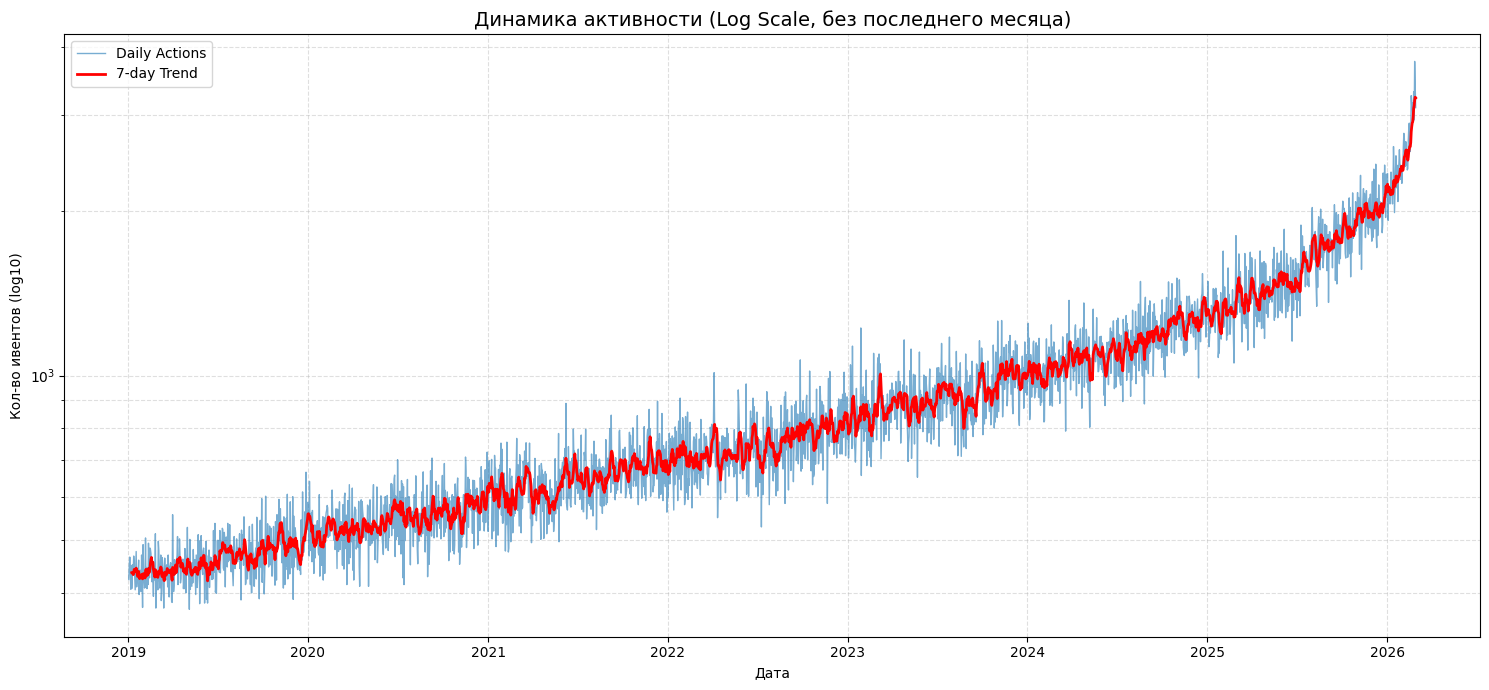

In [125]:
import polars as pl
import matplotlib.pyplot as plt

def plot_activity_log_scale(df_lazy):
    # 1. Агрегация данных по дням
    activity_df = (
        df_lazy
        .with_columns(
            date = pl.col("created_at")
                   .str.to_datetime(format="%Y-%m-%d %H:%M:%S%z", exact=False, strict=False)
                   .dt.truncate("1d")
        )
        .filter(pl.col("date").is_not_null())
        # --- ФИЛЬТР: Убираем последний месяц ---
        .with_columns(max_date = pl.col("date").max())
        .filter(pl.col("date") < pl.col("max_date").dt.truncate("1mo"))
        # ---------------------------------------
        .group_by("date")
        .agg(pl.len().alias("actions_count"))
        .sort("date")
        .collect()
    )

    # 2. Визуализация
    plt.figure(figsize=(15, 7))
    
    # Основная линия
    plt.plot(activity_df["date"], activity_df["actions_count"], 
             color='#1f77b4', linewidth=1, alpha=0.6, label="Daily Actions")
    
    # Скользящее среднее (7 дней)
    moving_avg = activity_df["actions_count"].rolling_mean(window_size=7)
    plt.plot(activity_df["date"], moving_avg, 
             color='red', linewidth=2, label="7-day Trend")

    # --- ЛОГАРИФМИЧЕСКИЙ МАСШТАБ ---
    plt.yscale('log')
    # -------------------------------

    plt.title("Динамика активности (Log Scale, без последнего месяца)", fontsize=14)
    plt.xlabel("Дата")
    plt.ylabel("Кол-во ивентов (log10)")
    plt.grid(True, which="both", linestyle='--', alpha=0.4) # which="both" для лог-сетки
    plt.legend()
    plt.tight_layout()
    plt.show()

# --- ЗАПУСК ---
plot_activity_log_scale(events_filled)

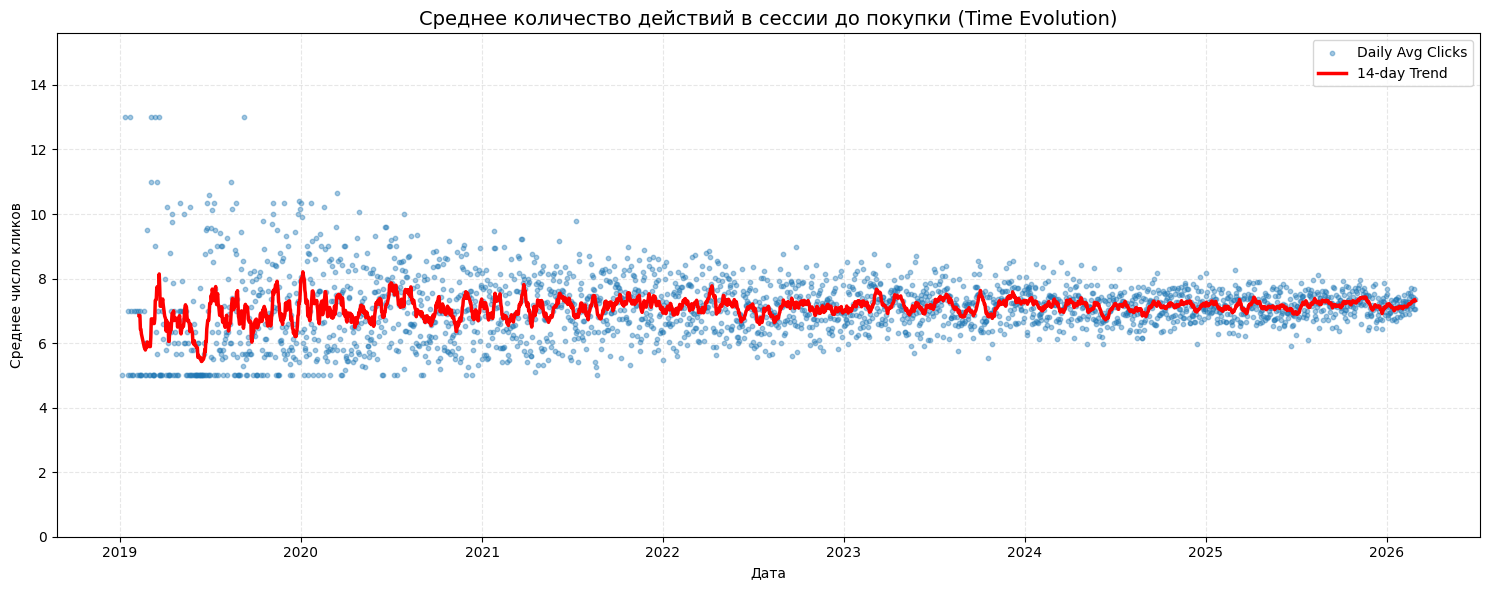

In [126]:
import polars as pl
import matplotlib.pyplot as plt

def plot_avg_clicks_to_purchase(df_lazy):
    # 1. Находим сессии с покупками и считаем количество действий в них
    purchase_sessions = (
        df_lazy
        .group_by("session_id")
        .agg([
            # Проверяем наличие покупки в сессии
            (pl.col("event_type") == "purchase").any().alias("is_purchased"),
            # Берем максимальный номер действия (длина пути)
            pl.col("sequence_number").max().alias("clicks_count"),
            # Берем дату покупки (или начала сессии) для временной оси
            pl.col("created_at").min().str.to_datetime(format="%Y-%m-%d %H:%M:%S%z", exact=False, strict=False).alias("date")
        ])
        .filter(pl.col("is_purchased")) # Оставляем только успешные сессии
        .with_columns(
            date = pl.col("date").dt.truncate("1d") # Группируем по дням
        )
    )

    # 2. Убираем последний месяц и считаем среднее по дням
    final_df = (
        purchase_sessions
        .filter(pl.col("date").is_not_null())
        .with_columns(max_date = pl.col("date").max())
        .filter(pl.col("date") < pl.col("max_date").dt.truncate("1mo"))
        .group_by("date")
        .agg(pl.col("clicks_count").mean().alias("avg_clicks"))
        .sort("date")
        .collect()
    )

    # 3. Визуализация
    plt.figure(figsize=(15, 6))
    
    # Точки данных (дневные средние)
    plt.scatter(final_df["date"], final_df["avg_clicks"], 
                color='#1f77b4', s=10, alpha=0.4, label="Daily Avg Clicks")
    
    # Трендовая линия (скользящее среднее за 14 дней для стабильности)
    trend = final_df["avg_clicks"].rolling_mean(window_size=14)
    plt.plot(final_df["date"], trend, color='red', linewidth=2.5, label="14-day Trend")

    plt.title("Среднее количество действий в сессии до покупки (Time Evolution)", fontsize=14)
    plt.xlabel("Дата")
    plt.ylabel("Среднее число кликов")
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.legend()
    
    # Установим лимиты Y, чтобы видеть колебания (от 0 до чуть выше максимума)
    if not final_df.is_empty():
        plt.ylim(0, final_df["avg_clicks"].max() * 1.2)

    plt.tight_layout()
    plt.show()

# --- ЗАПУСК ---
plot_avg_clicks_to_purchase(events_filled)